In [1]:
import pandas as pd

X_train = pd.read_csv("train_input_Z61KlZo.csv")
y_train = pd.read_csv("train_output_DzPxaPY.csv")
X_test = pd.read_csv("test_input_5qJzHrr.csv")
y_pred_random = pd.read_csv("test_output_random.csv")

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

C:\Users\ilyes\AppData\Local\Temp\ipykernel_15324\3708914782.py:3: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train = pd.read_csv("train_input_Z61KlZo.csv")
C:\Users\ilyes\AppData\Local\Temp\ipykernel_15324\3708914782.py:5: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test = pd.read_csv("test_input_5qJzHrr.csv")


Train: (383610, 374)
Test: (95852, 374)


In [2]:
from sklearn.model_selection import train_test_split

X_train_train, X_train_test, y_train_train, y_train_test = train_test_split(X_train, y_train, test_size=X_test.shape[0], random_state=42)

In [3]:
from sklearn.metrics import root_mean_squared_error

def rmse(y1, y2):
    return round(root_mean_squared_error(y1['CHARGE'], y2['CHARGE']), 2)

# Random

In [33]:
import numpy as np

# local
y_train_pred_random = y_train_test.copy()
y_train_pred_random['CHARGE'] = np.random.choice(y_train_train['CHARGE'], size=len(y_train_test))

rmse(y_train_test, y_train_pred_random)

9034.89

# Zero

In [26]:
# local
y_train_pred_zero = y_train_test.copy()
y_train_pred_zero['CHARGE'] = 0

rmse(y_train_test, y_train_pred_zero)

6837.83

In [34]:
# submission
y_pred_zero = y_pred_random.copy()
y_pred_zero['CHARGE'] = 0
y_pred_zero.to_csv('Submissions/submission_zero.csv', index=False)

# Preprocessing

In [7]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

def X_preprocessing(X_train, X_test):
    # Numerical: median imputation
    # Categorical: most frequent imputation + one-hot encoding

    # separate columns + remove 'ID'
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    num_cols.remove('ID')
    cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    # mixed types -> strings only
    X_train[cat_cols] = X_train[cat_cols].astype(str)
    X_test[cat_cols] = X_test[cat_cols].astype(str)

    # pipelines
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ])
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

    # fit transform
    X_train_clean = preprocessor.fit_transform(X_train)
    X_test_clean = preprocessor.transform(X_test)

    # feature names
    num_features = num_cols
    cat_features = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols)
    all_features = num_features + cat_features.tolist()

    # dataframes
    X_train_clean = pd.DataFrame(X_train_clean, columns=all_features)
    X_test_clean = pd.DataFrame(X_test_clean, columns=all_features)

    return X_train_clean, X_test_clean

In [ ]:
X_train_train_clean, X_train_test_clean = X_preprocessing(X_train_train, X_train_test)

,TYPERS,ANCIENNETE,CARACT2,DUREE_REQANEUF,CARACT5,TYPBAT2,DEROG15,CA1,CA2,CA3,...,NBJRR30_MSOM_A,NBJRR100_MM_A,NBJRR100_MMAX_A,NBJRR100_MSOM_A,RR_VOR_MM_A,RR_VOR_MMAX_A,RRAB_VOR_MM_A,RRAB_VOR_MMAX_A,ESPINSEE,AN_EXERC
0,1.0,0.0,1.0,2.0,2.0,0.0,100.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,2.0,0.0,2.0,8.0
1,1.0,11.0,1.0,2.0,0.0,1.0,100.0,0.0,0.0,0.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,8.0
2,2.0,4.0,1.0,2.0,0.0,1.0,100.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,6.0
3,2.0,9.0,1.0,2.0,0.0,2.0,100.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,2.0,1.0,2.0,0.0,2.0,5.0
4,2.0,11.0,1.0,2.0,0.0,2.0,100.0,0.0,0.0,0.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287753,2.0,0.0,1.0,2.0,0.0,0.0,100.0,0.0,0.0,0.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,7.0
287754,1.0,6.0,1.0,2.0,0.0,0.0,100.0,0.0,0.0,0.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,5.0
287755,2.0,10.0,1.0,2.0,0.0,2.0,100.0,0.0,0.0,0.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0
287756,2.0,9.0,1.0,2.0,0.0,2.0,100.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,2.0,3.0,3.0,1.0,4.0,0.0


# Decision Trees

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# local
y_train_pred_dt = y_train_test.copy()

targets = ['FREQ', 'CM', 'ANNEE_ASSURANCE']

for target in targets:
    y_train_col = y_train_train[target]
    model = DecisionTreeRegressor(max_depth=5, random_state=42)
    model.fit(X_train_train_clean, y_train_col)
    preds = model.predict(X_train_test_clean)
    y_train_pred_dt[target] = preds

y_train_pred_dt['CHARGE'] = y_train_pred_dt['FREQ'] * y_train_pred_dt['CM'] * y_train_pred_dt['ANNEE_ASSURANCE']

In [35]:
X_train_clean, X_test_clean = X_preprocessing(X_train, X_test)

In [36]:
from sklearn.tree import DecisionTreeRegressor

# submission
y_pred_dt = y_pred_random.copy()

targets = ['FREQ', 'CM', 'ANNEE_ASSURANCE']

for target in targets:
    y_train_col = y_train[target]
    model = DecisionTreeRegressor(max_depth=5, random_state=42)
    model.fit(X_train_clean, y_train_col)
    preds = model.predict(X_test_clean)
    y_pred_dt[target] = preds

y_pred_dt['CHARGE'] = y_pred_dt['FREQ'] * y_pred_dt['CM'] * y_pred_dt['ANNEE_ASSURANCE']

y_pred_dt.to_csv('Submissions/submission_dt5.csv', index=False)

# Compare Models

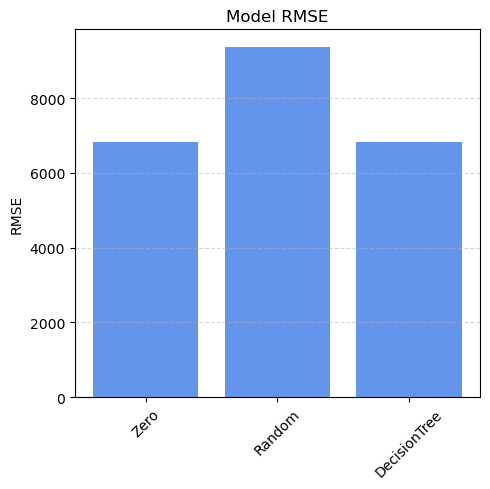

In [22]:
import matplotlib.pyplot as plt

train_pred_dict = {
    'Zero': y_train_pred_zero,
    'Random': y_train_pred_random,
    'DecisionTree': y_train_pred_dt,
}

rmse_scores = {name: rmse(y_train_test, pred) for name, pred in train_pred_dict.items()}

plt.figure(figsize=(5, 5))
plt.bar(rmse_scores.keys(), rmse_scores.values(), color='cornflowerblue')
plt.ylabel('RMSE')
plt.title('Model RMSE')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()